# Uber project

<m>

## 1. Data wrangling and preparation

<m>

### 1.1 Import and read data

<m>

In [2]:
import pandas as pd
import numpy as np
import janitor as janitor
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from scipy import stats
import statsmodels.api as sm
from statsmodels.api import OLS
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
import psycopg2
import re
import ast
import openpyxl
import pyarrow
from fuzzywuzzy import fuzz,process
import geopandas as gpd
import warnings as warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')
%matplotlib inline

C:\Users\Fo2sh\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df=pd.read_csv('ncr_ride_bookings.csv')

In [4]:
df.head(5)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


<m>

### 1.2 Exploratory data analysis (EDA)


<m>

In [5]:
#report=sv.analyze(df)
#report.show_html('profiling_report.html')

In [6]:
df.shape

(150000, 21)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [8]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [9]:
df.dtypes

Date                                     str
Time                                     str
Booking ID                               str
Booking Status                           str
Customer ID                              str
Vehicle Type                             str
Pickup Location                          str
Drop Location                            str
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer        str
Cancelled Rides by Driver            float64
Driver Cancellation Reason               str
Incomplete Rides                     float64
Incomplete Rides Reason                  str
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                           str
dtype: object

In [10]:
df.index

RangeIndex(start=0, stop=150000, step=1)

In [11]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [12]:
print(df.duplicated(subset=['Booking ID','Customer ID']).sum())

0


<m>

### 1.3 Preparing data

<m>

In [13]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='str')

In [14]:
df.rename(columns={'Vehicle Type':'Booking Type','Avg VTAT':'Average Vehicle Time at Arrival','Avg CTAT':'Average Customer Time at Arrival'},inplace=True)

In [15]:
new_order=['Booking ID','Booking Status','Booking Type','Booking Value','Payment Method','Driver Ratings','Average Vehicle Time at Arrival',
           'Cancelled Rides by Driver','Driver Cancellation Reason',
           'Customer ID','Customer Rating','Average Customer Time at Arrival','Cancelled Rides by Customer','Reason for cancelling by Customer',
           'Pickup Location','Drop Location','Ride Distance','Incomplete Rides', 'Incomplete Rides Reason']

In [16]:
df=df[new_order]

In [17]:
df=df.clean_names()

<m>

### 1.3.1 Dealing with nulls

<m>

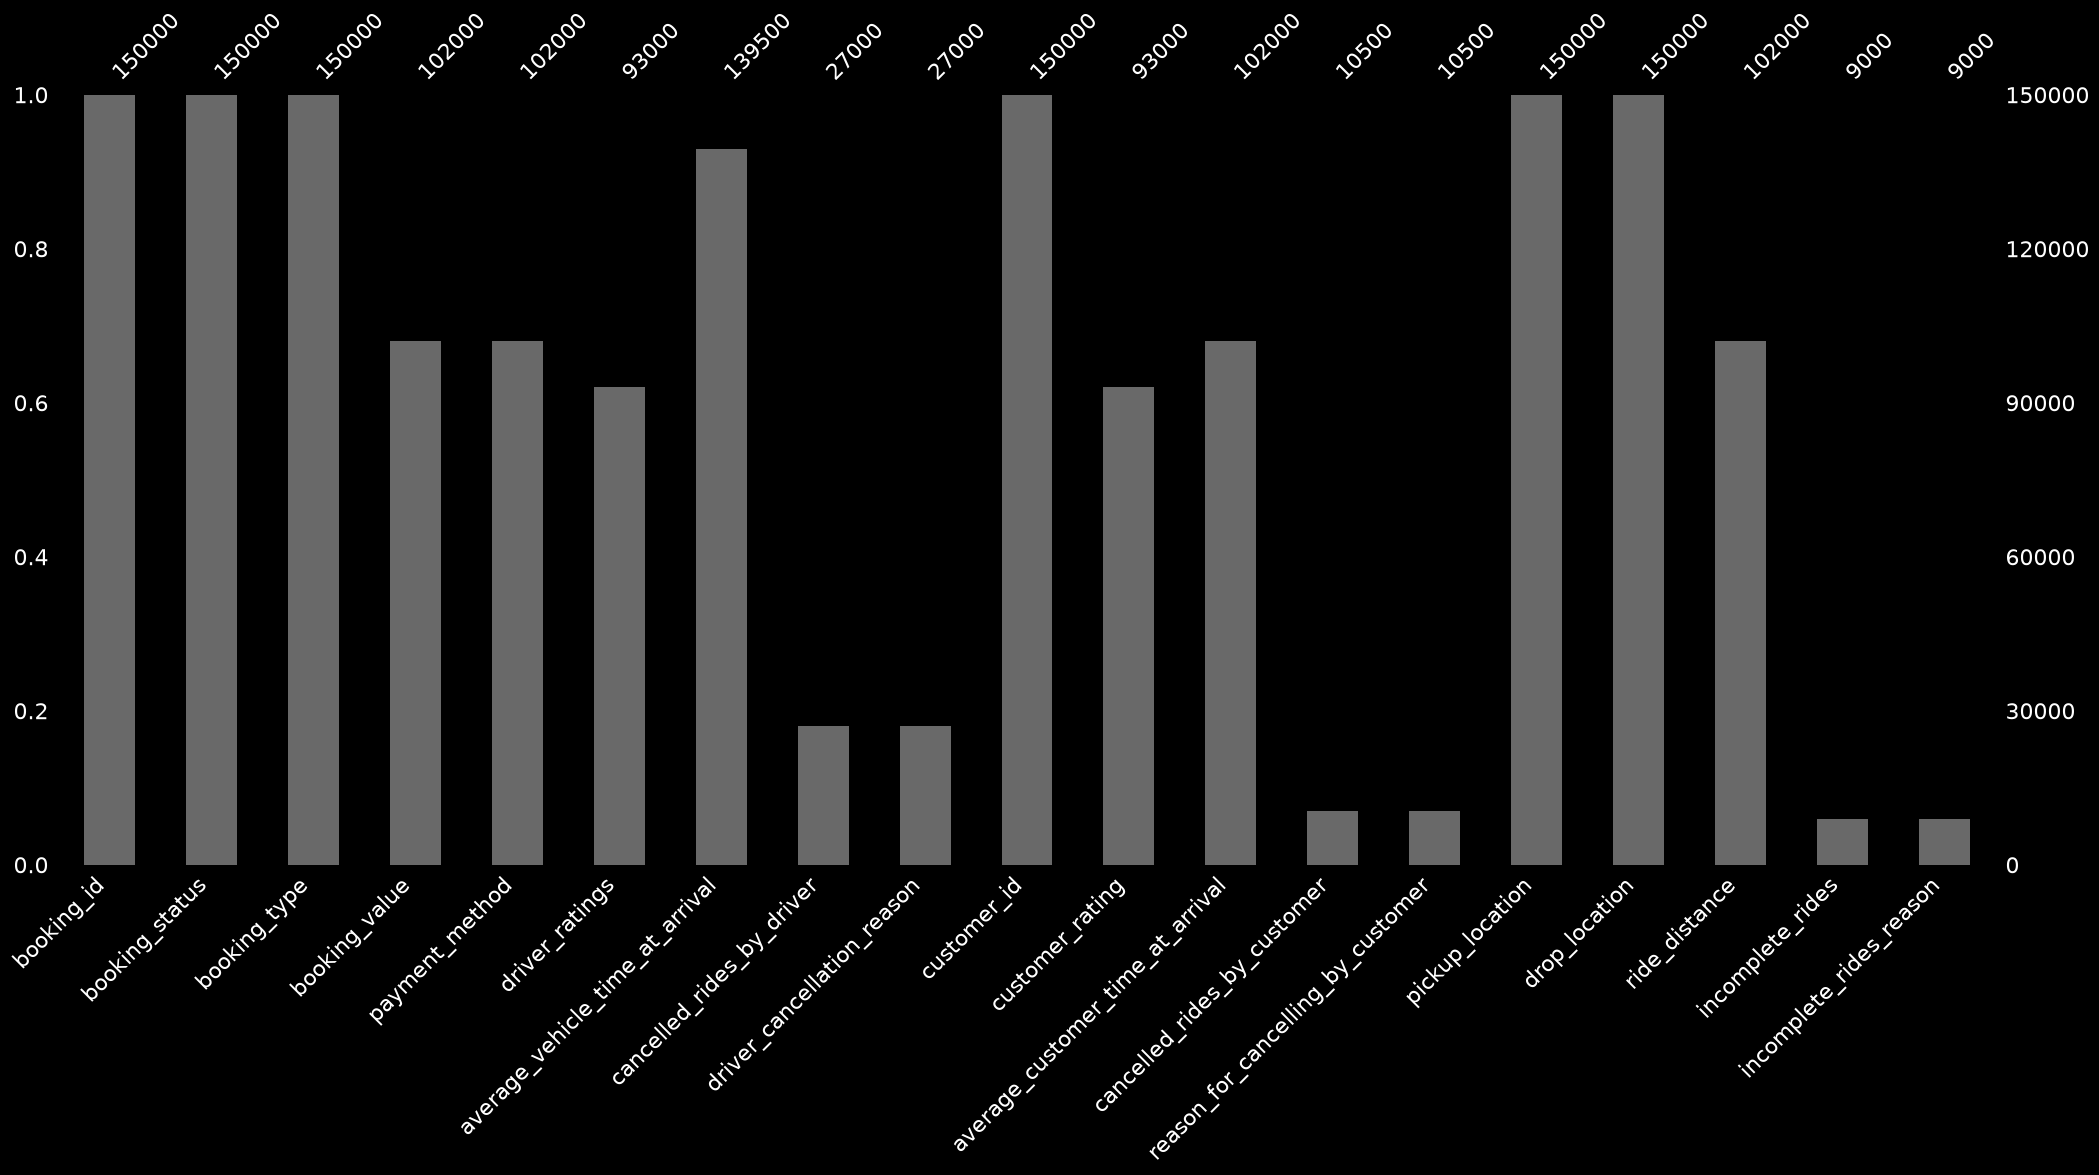

In [18]:
msno.bar(df)
plt.show()

In [19]:
df.isnull().sum()

booking_id                                0
booking_status                            0
booking_type                              0
booking_value                         48000
payment_method                        48000
driver_ratings                        57000
average_vehicle_time_at_arrival       10500
cancelled_rides_by_driver            123000
driver_cancellation_reason           123000
customer_id                               0
customer_rating                       57000
average_customer_time_at_arrival      48000
cancelled_rides_by_customer          139500
reason_for_cancelling_by_customer    139500
pickup_location                           0
drop_location                             0
ride_distance                         48000
incomplete_rides                     141000
incomplete_rides_reason              141000
dtype: int64

In [20]:
df['payment_method']=df['payment_method'].fillna('incompleted ride',inplace=True)

In [21]:
df['incomplete_rides_reason']=df['incomplete_rides_reason'].fillna('Unknown',inplace=True)

In [22]:
df['reason_for_cancelling_by_customer']=df['reason_for_cancelling_by_customer'].fillna('Unknown',inplace=True)

In [23]:
df['driver_cancellation_reason']=df['driver_cancellation_reason'].fillna('Unknown',inplace=True)

In [24]:
df=df.fillna({'booking_value':0,
         'cancelled_rides_by_driver':0,
         'cancelled_rides_by_customer':0,
         'incomplete_rides':0,
         'driver_ratings':0,
          'customer_rating':0,
           'ride_distance':0,
           'average_customer_time_at_arrival':0,
           'average_vehicle_time_at_arrival':0
          },inplace=True)

In [25]:
df.isnull().sum()

booking_id                           0
booking_status                       0
booking_type                         0
booking_value                        0
payment_method                       0
driver_ratings                       0
average_vehicle_time_at_arrival      0
cancelled_rides_by_driver            0
driver_cancellation_reason           0
customer_id                          0
customer_rating                      0
average_customer_time_at_arrival     0
cancelled_rides_by_customer          0
reason_for_cancelling_by_customer    0
pickup_location                      0
drop_location                        0
ride_distance                        0
incomplete_rides                     0
incomplete_rides_reason              0
dtype: int64

<m>

### 1.3.2 Dealing with outliers

##### Z-score - IQR

<m>

In [26]:
numeric_columns = df.select_dtypes(include='number')

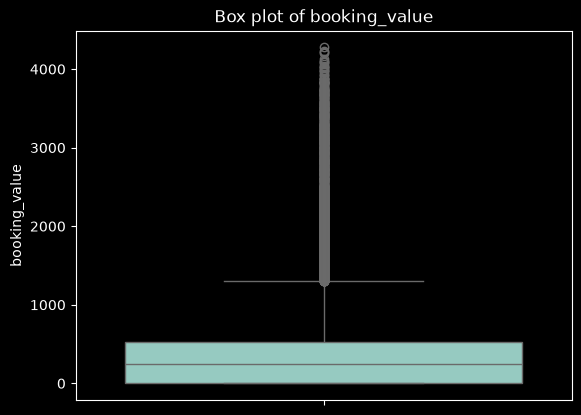

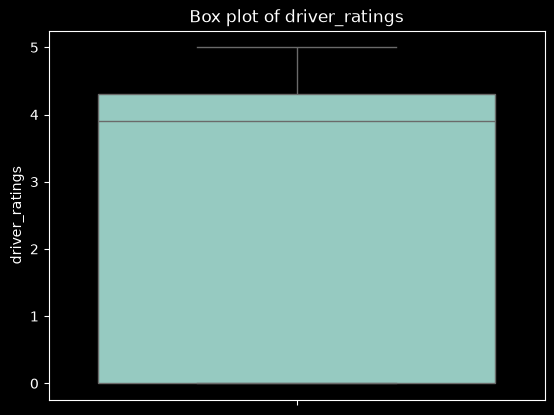

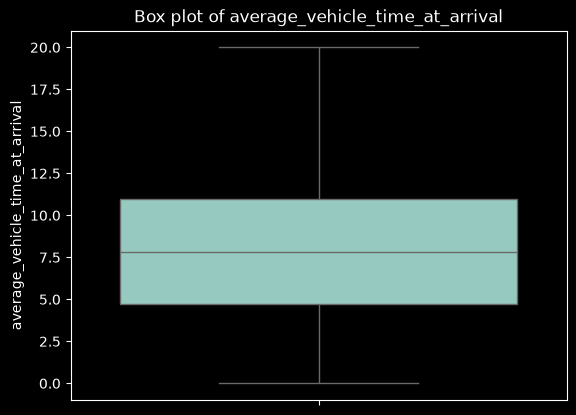

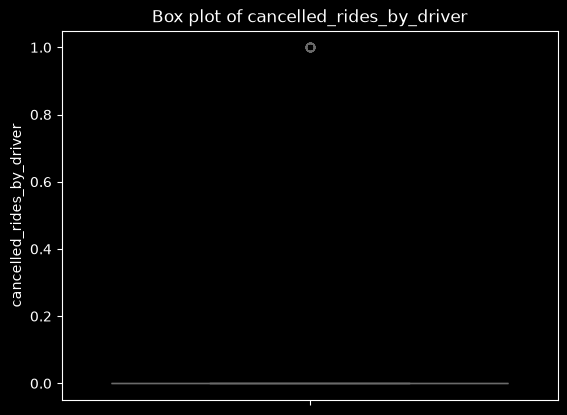

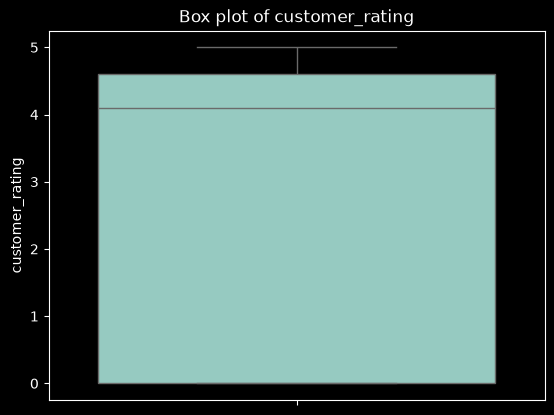

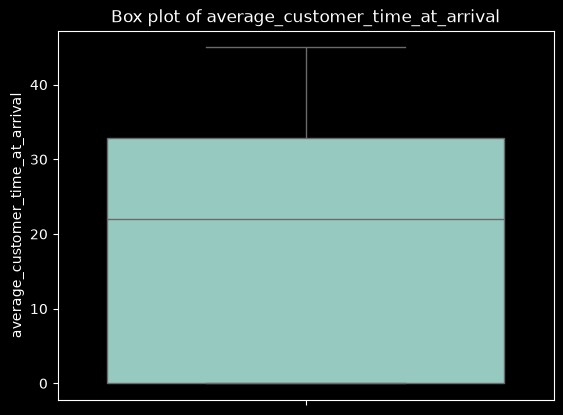

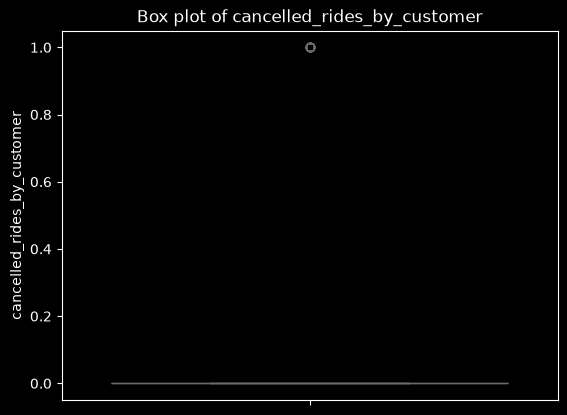

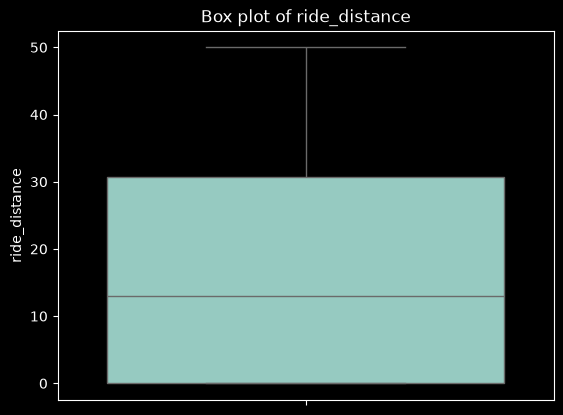

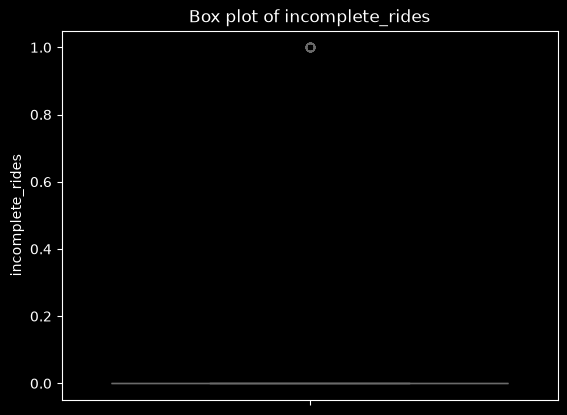

In [27]:
for column in numeric_columns:
    sns.boxplot(df[column])
    plt.title(f'Box plot of {column}')
    plt.show()

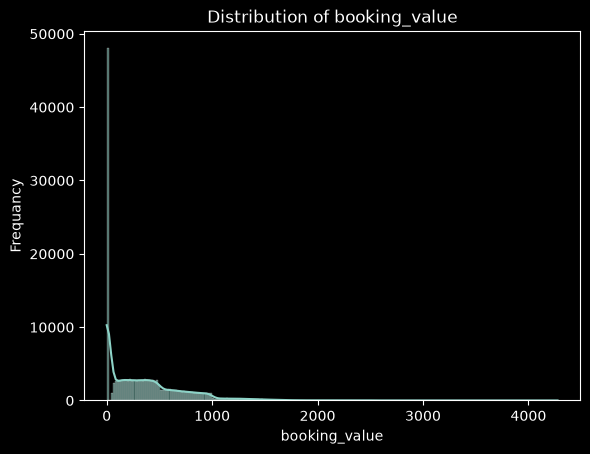

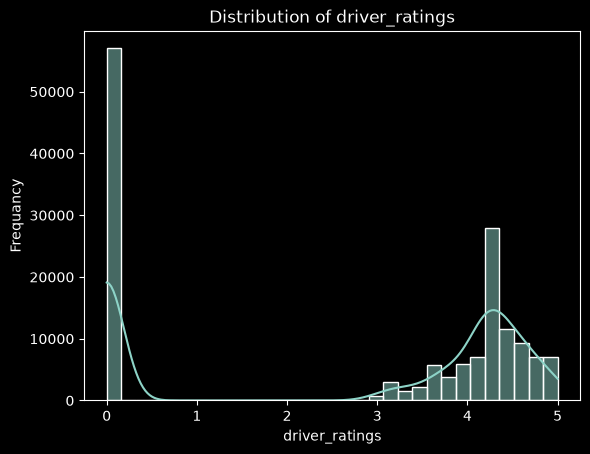

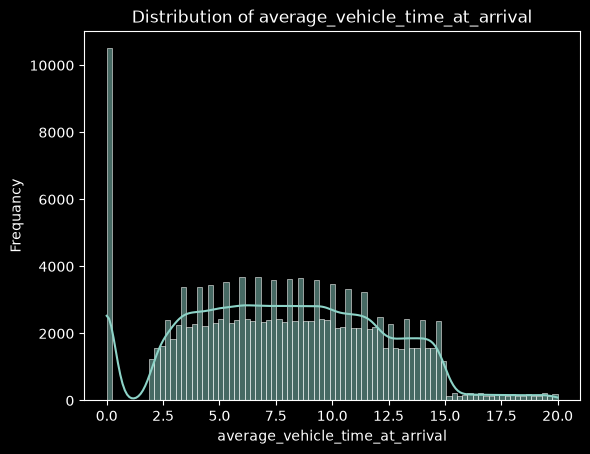

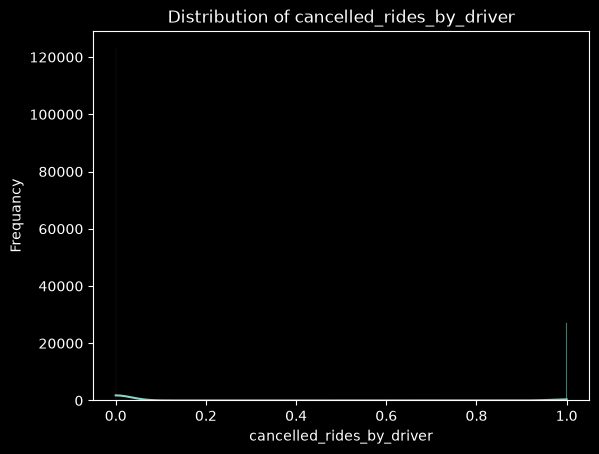

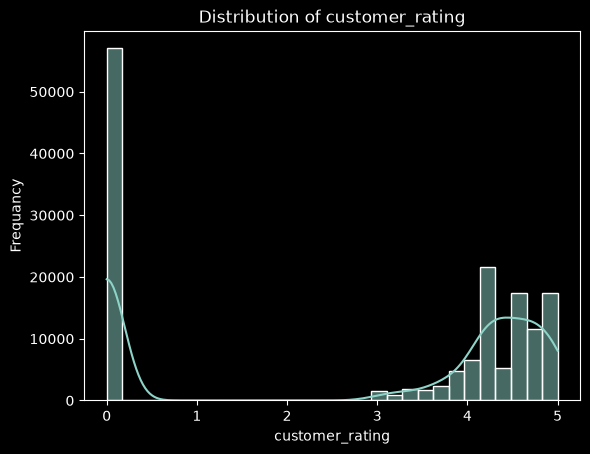

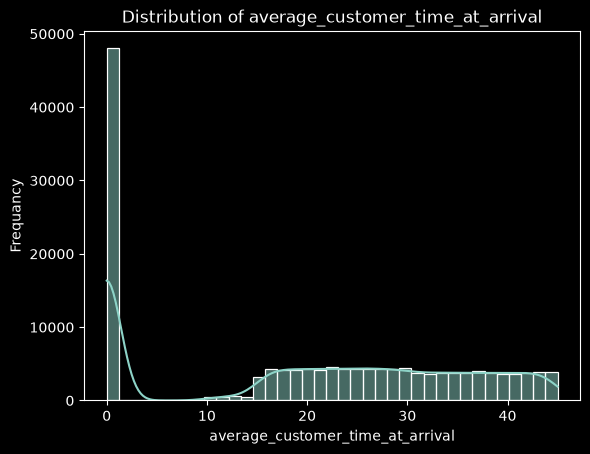

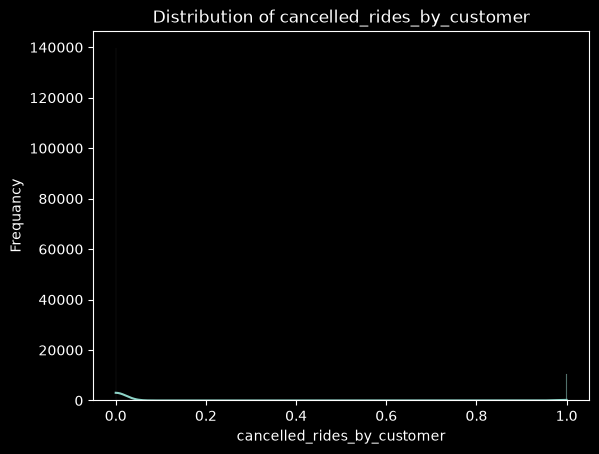

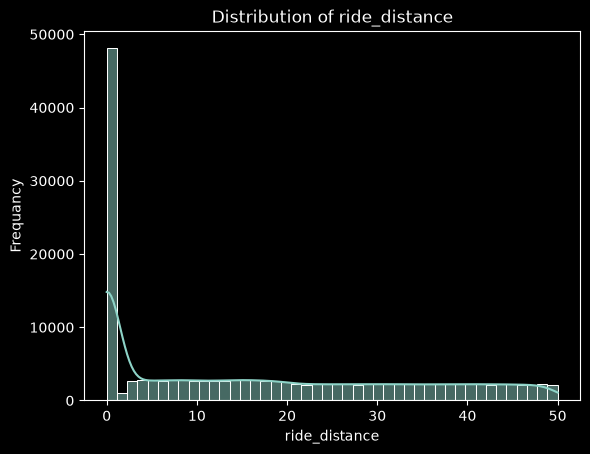

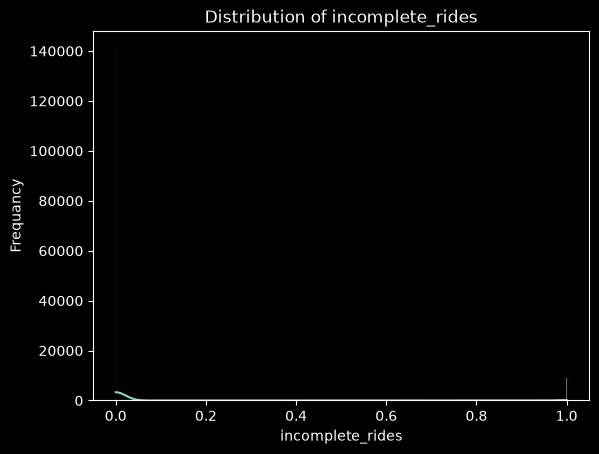

In [28]:
for column in numeric_columns:
    sns.histplot(df[column],kde=True)
    plt.title(f'Distribution of {column}')
    plt.ylabel('Frequancy')
    plt.show()

In [29]:
numeric_columns.skew()

booking_value                       2.103978
driver_ratings                     -0.414892
average_vehicle_time_at_arrival     0.065788
cancelled_rides_by_driver           1.665870
customer_rating                    -0.421556
average_customer_time_at_arrival   -0.111143
cancelled_rides_by_customer         3.370639
ride_distance                       0.513758
incomplete_rides                    3.705506
dtype: float64

<m>

##### IQR

<m>

In [30]:
def detect_outliers_value_iqr_values(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    upper_bond=q3+1.5*iqr
    lower_bond=q1-1.5*iqr
    print(f'Upper bond : {upper_bond}\nLower bond : {lower_bond}')

In [31]:
def detect_outliers_value_iqr_sample(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    upper_bond=q3+1.5*iqr
    lower_bond=q1-1.5*iqr
    return df[(df[column]>upper_bond) | (df[column]<lower_bond)].head()

In [32]:
def detect_outliers_value_iqr_population(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    upper_bond=q3+1.5*iqr
    lower_bond=q1-1.5*iqr
    return df[(df[column]>upper_bond) | (df[column]<lower_bond)]

<m>

##### IQR for booking_value with skewness : 2.10

<m>

In [33]:
detect_outliers_value_iqr_values(df,'booking_value')

Upper bond : 1302.5
Lower bond : -781.5


In [34]:
detect_outliers_value_iqr_sample(df,'booking_value')

,booking_id,booking_status,booking_type,booking_value,payment_method,driver_ratings,average_vehicle_time_at_arrival,cancelled_rides_by_driver,driver_cancellation_reason,customer_id,customer_rating,average_customer_time_at_arrival,cancelled_rides_by_customer,reason_for_cancelling_by_customer,pickup_location,drop_location,ride_distance,incomplete_rides,incomplete_rides_reason
29,"""CNR8779845""",Completed,Auto,2847.0,Debit Card,3.1,8.9,0.0,Unknown,"""CID7444351""",4.6,31.1,0.0,Unknown,Faridabad Sector 15,Malviya Nagar,39.21,0.0,Unknown
50,"""CNR1572483""",Incomplete,Go Mini,1581.0,Cash,0.0,9.9,0.0,Unknown,"""CID6059557""",0.0,21.6,0.0,Unknown,Rajiv Chowk,Central Secretariat,1.82,1.0,Vehicle Breakdown
80,"""CNR4487090""",Completed,Premier Sedan,1390.0,UPI,5.0,9.6,0.0,Unknown,"""CID1210782""",4.9,39.1,0.0,Unknown,Lajpat Nagar,Chirag Delhi,21.79,0.0,Unknown
91,"""CNR7449144""",Completed,Auto,2169.0,Uber Wallet,4.4,8.6,0.0,Unknown,"""CID8609350""",4.3,32.7,0.0,Unknown,IGNOU Road,Tis Hazari,44.25,0.0,Unknown
212,"""CNR5269641""",Completed,Go Mini,1543.0,Cash,4.4,12.3,0.0,Unknown,"""CID8225890""",5.0,34.6,0.0,Unknown,IIT Delhi,Basai Dhankot,49.71,0.0,Unknown


In [35]:
bv_pop=detect_outliers_value_iqr_population(df,'booking_value')

In [36]:
bv_pop.sort_values(by='booking_value',ascending=False).head()

,booking_id,booking_status,booking_type,booking_value,payment_method,driver_ratings,average_vehicle_time_at_arrival,cancelled_rides_by_driver,driver_cancellation_reason,customer_id,customer_rating,average_customer_time_at_arrival,cancelled_rides_by_customer,reason_for_cancelling_by_customer,pickup_location,drop_location,ride_distance,incomplete_rides,incomplete_rides_reason
7450,"""CNR7954315""",Completed,Go Mini,4277.0,UPI,4.7,9.5,0.0,Unknown,"""CID2706299""",4.9,17.2,0.0,Unknown,Saidulajab,Netaji Subhash Place,8.66,0.0,Unknown
83506,"""CNR1798489""",Completed,Bike,4228.0,Debit Card,4.4,14.2,0.0,Unknown,"""CID4843078""",5.0,41.5,0.0,Unknown,Ashram,Patel Chowk,11.73,0.0,Unknown
2731,"""CNR8487909""",Completed,Auto,4220.0,UPI,3.6,6.6,0.0,Unknown,"""CID2978596""",4.8,15.6,0.0,Unknown,Welcome,Jama Masjid,10.11,0.0,Unknown
90418,"""CNR5182516""",Completed,Auto,4202.0,Uber Wallet,4.9,14.0,0.0,Unknown,"""CID5235759""",4.7,21.8,0.0,Unknown,Subhash Nagar,Laxmi Nagar,4.62,0.0,Unknown
7116,"""CNR7356012""",Completed,Go Mini,4133.0,Cash,3.9,9.3,0.0,Unknown,"""CID5789715""",4.3,44.0,0.0,Unknown,IMT Manesar,Sarojini Nagar,25.66,0.0,Unknown


In [37]:
print(df['booking_value'].max())

4277.0


In [38]:
one_mile_price_check=df[df['ride_distance']==1]

In [39]:
print(one_mile_price_check['booking_value'].mean())

854.5


##### Based on the established average rate of 850 per mile, a fare of 4,000 does not qualify as an outlier. The pricing model is directly proportional to ride distance, meaning longer trips naturally result in higher fares. In this case, a fare of 4,000 corresponds to an expected ride length of approximately 4.7 miles, which is consistent with the standard rate structure.

<m>

##### Z-Score

<m>

In [40]:
def detect_outliers_z_score_values(df,column):
    upper_limit=df[column].mean()+3*df[column].std()
    lower_limit=df[column].mean()-3*df[column].std()
    print(f'Upper Limit : {upper_limit}\nLower Limit : {lower_limit}')

In [41]:
def detect_outliers_z_score_sample(df,column):
    upper_limit=df[column].mean()+3*df[column].std()
    lower_limit=df[column].mean()-3*df[column].std()
    return df[(df[column]>upper_limit) | (df[column]<lower_limit)].head()

In [42]:
def detect_outliers_z_score_population(df,column):
    upper_limit=df[column].mean()+3*df[column].std()
    lower_limit=df[column].mean()-3*df[column].std()
    return df[(df[column]>upper_limit) | (df[column]<lower_limit)]

<m>

##### Z-Score for driver_rating with skewness: -0.41

In [43]:
detect_outliers_z_score_values(df,'driver_ratings')

Upper Limit : 8.870065722845576
Lower Limit : -3.623635056178909


In [44]:
detect_outliers_z_score_sample(df,'driver_ratings')

,booking_id,booking_status,booking_type,booking_value,payment_method,driver_ratings,average_vehicle_time_at_arrival,cancelled_rides_by_driver,driver_cancellation_reason,customer_id,customer_rating,average_customer_time_at_arrival,cancelled_rides_by_customer,reason_for_cancelling_by_customer,pickup_location,drop_location,ride_distance,incomplete_rides,incomplete_rides_reason


##### There is no outliers in driver rating

<m>

##### Z-Score for custumer_rating with skewness: -0.42

In [45]:
detect_outliers_z_score_values(df,'customer_rating')

Upper Limit : 9.227486896813286
Lower Limit : -3.7658028968132853


In [46]:
detect_outliers_z_score_sample(df,'customer_rating')

,booking_id,booking_status,booking_type,booking_value,payment_method,driver_ratings,average_vehicle_time_at_arrival,cancelled_rides_by_driver,driver_cancellation_reason,customer_id,customer_rating,average_customer_time_at_arrival,cancelled_rides_by_customer,reason_for_cancelling_by_customer,pickup_location,drop_location,ride_distance,incomplete_rides,incomplete_rides_reason


##### There is no outliers in customer rating

<m>

##### Z-Score for average_vehicle_time_at_arrival with skewness: -0.06

In [47]:
detect_outliers_z_score_values(df,'average_vehicle_time_at_arrival')

Upper Limit : 20.556328187079195
Lower Limit : -4.827513520412527


In [48]:
detect_outliers_z_score_sample(df,'average_vehicle_time_at_arrival')

,booking_id,booking_status,booking_type,booking_value,payment_method,driver_ratings,average_vehicle_time_at_arrival,cancelled_rides_by_driver,driver_cancellation_reason,customer_id,customer_rating,average_customer_time_at_arrival,cancelled_rides_by_customer,reason_for_cancelling_by_customer,pickup_location,drop_location,ride_distance,incomplete_rides,incomplete_rides_reason


##### There is no outliers in average_vehicle_time_at_arrival

<M>

##### Z-Score for average_customer_time_at_arrival with skewness: -0.11

In [49]:
detect_outliers_z_score_values(df,'average_customer_time_at_arrival')

Upper Limit : 66.18025332617167
Lower Limit : -26.536747992838333


In [50]:
detect_outliers_z_score_sample(df,'average_customer_time_at_arrival')

,booking_id,booking_status,booking_type,booking_value,payment_method,driver_ratings,average_vehicle_time_at_arrival,cancelled_rides_by_driver,driver_cancellation_reason,customer_id,customer_rating,average_customer_time_at_arrival,cancelled_rides_by_customer,reason_for_cancelling_by_customer,pickup_location,drop_location,ride_distance,incomplete_rides,incomplete_rides_reason


##### There is no outliers in average_vehicle_time_at_arrival

<M>

##### Z-Score for ride_distance with skewness: 0.51

In [51]:
detect_outliers_z_score_values(df,'ride_distance')

Upper Limit : 65.62652297143157
Lower Limit : -32.1201871047649


In [52]:
detect_outliers_z_score_sample(df,'ride_distance')

,booking_id,booking_status,booking_type,booking_value,payment_method,driver_ratings,average_vehicle_time_at_arrival,cancelled_rides_by_driver,driver_cancellation_reason,customer_id,customer_rating,average_customer_time_at_arrival,cancelled_rides_by_customer,reason_for_cancelling_by_customer,pickup_location,drop_location,ride_distance,incomplete_rides,incomplete_rides_reason


##### There is no outliers in average_vehicle_time_at_arrival

<m>

### 1.4 Understanding features

<m>

#### (Univariant analysis)

<m>

In [53]:
df.columns

Index(['booking_id', 'booking_status', 'booking_type', 'booking_value',
       'payment_method', 'driver_ratings', 'average_vehicle_time_at_arrival',
       'cancelled_rides_by_driver', 'driver_cancellation_reason',
       'customer_id', 'customer_rating', 'average_customer_time_at_arrival',
       'cancelled_rides_by_customer', 'reason_for_cancelling_by_customer',
       'pickup_location', 'drop_location', 'ride_distance', 'incomplete_rides',
       'incomplete_rides_reason'],
      dtype='str')

In [54]:
categorical_columns=df.select_dtypes(exclude='number')
categorical_columns = categorical_columns.drop(columns=['booking_id','customer_id'])

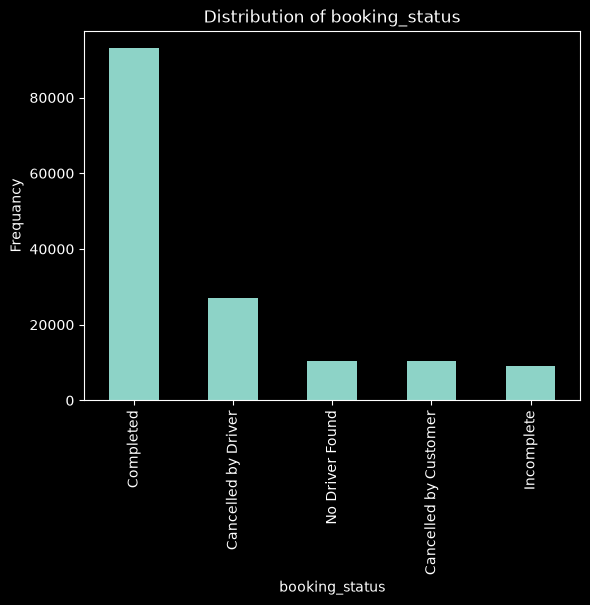

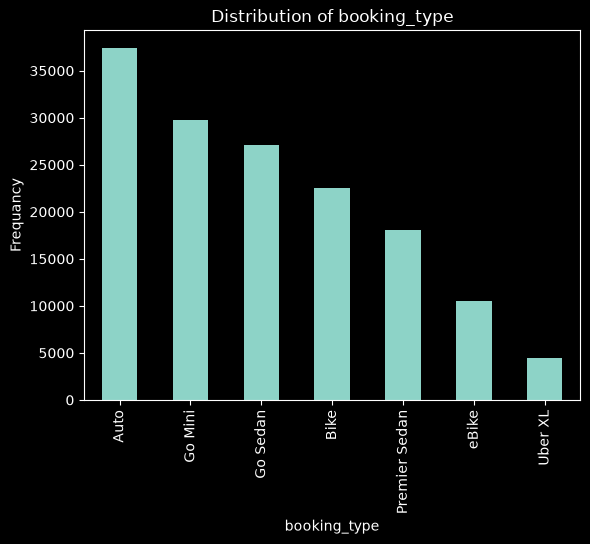

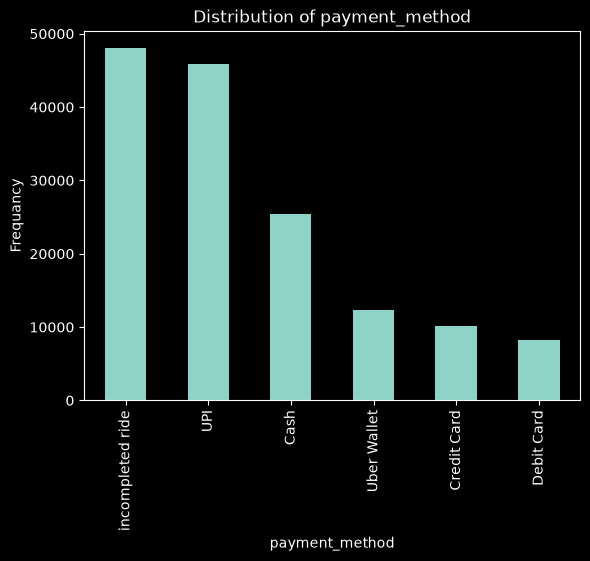

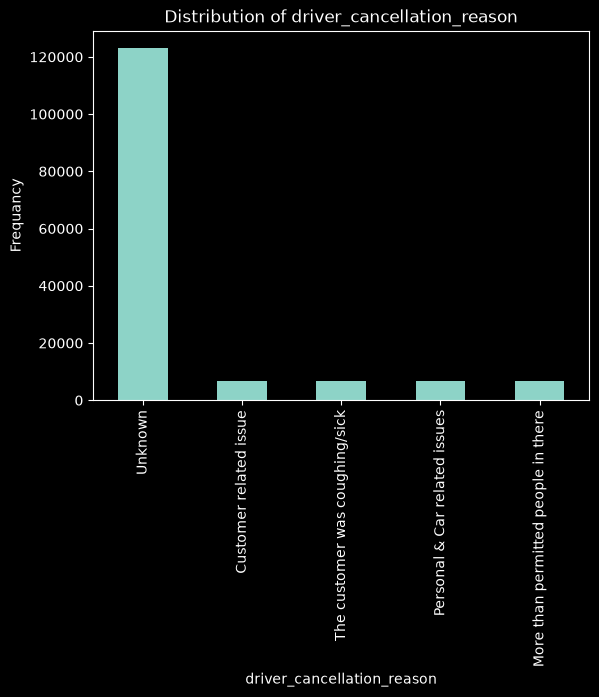

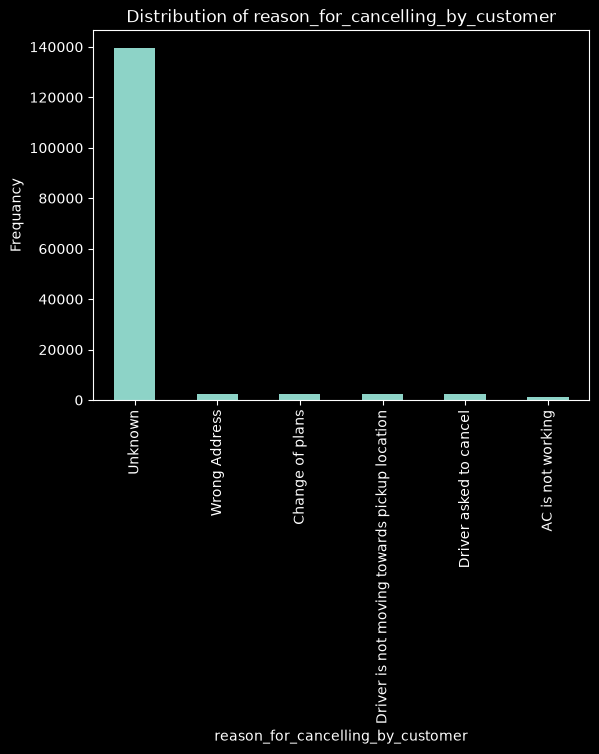

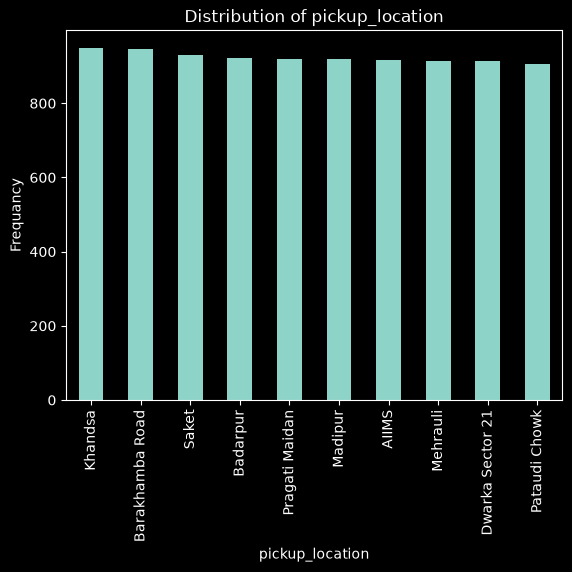

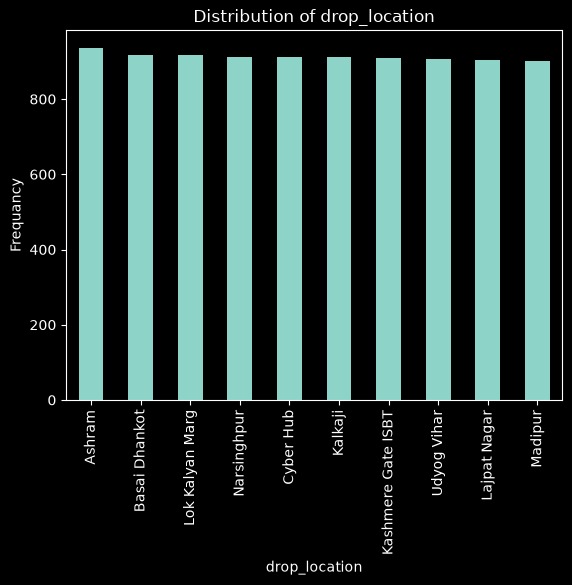

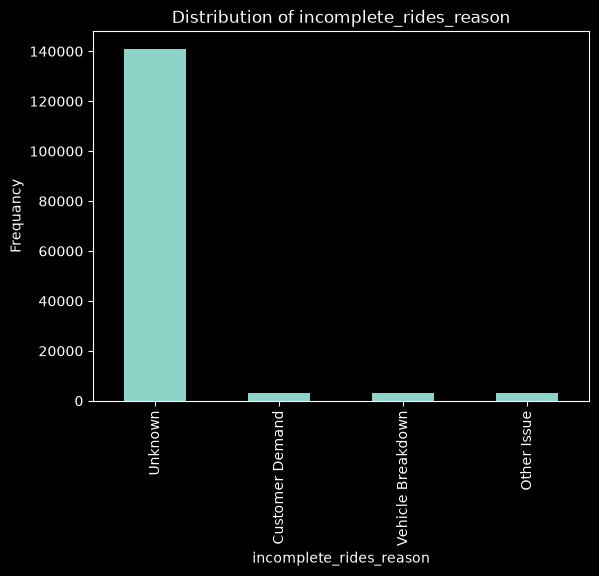

In [55]:
for column in categorical_columns:
    ax=df[column].value_counts().head(10).plot(kind='bar',title=f'Distribution of {column}')
    ax.set_xlabel(f'{column}')
    ax.set_ylabel('Frequancy')
    plt.show()

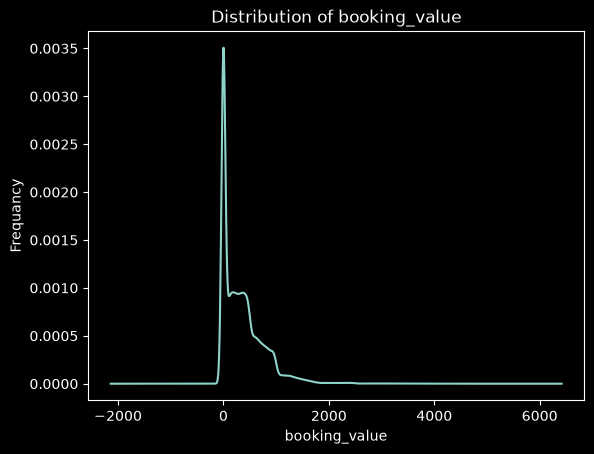

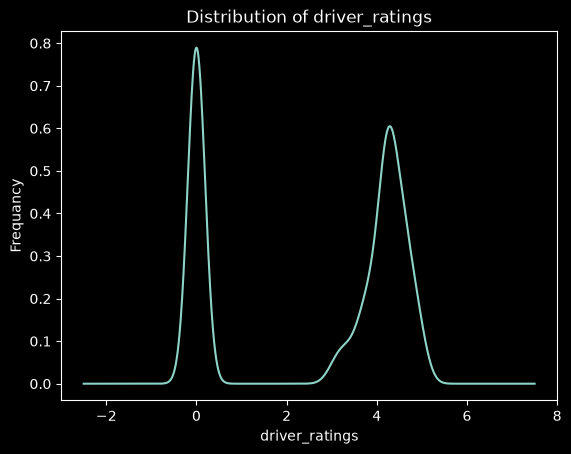

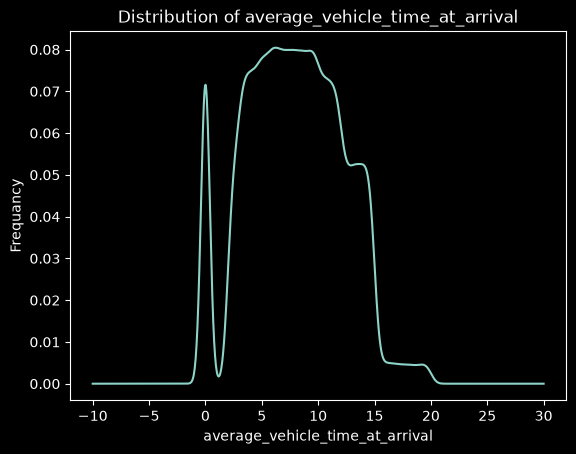

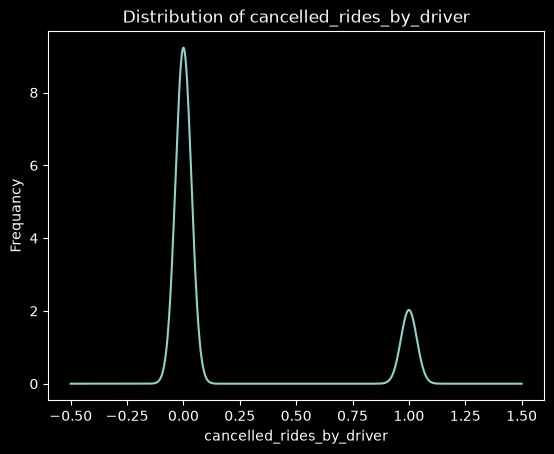

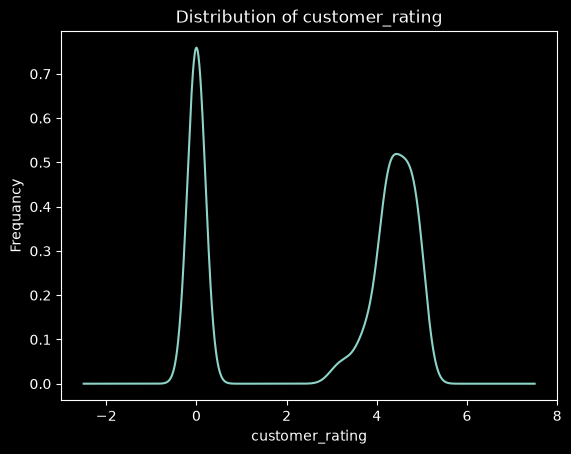

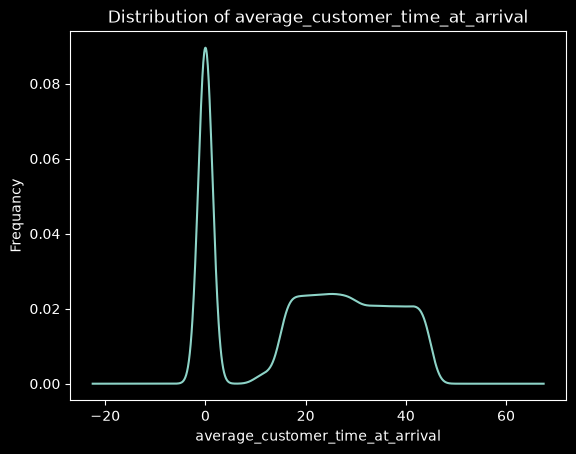

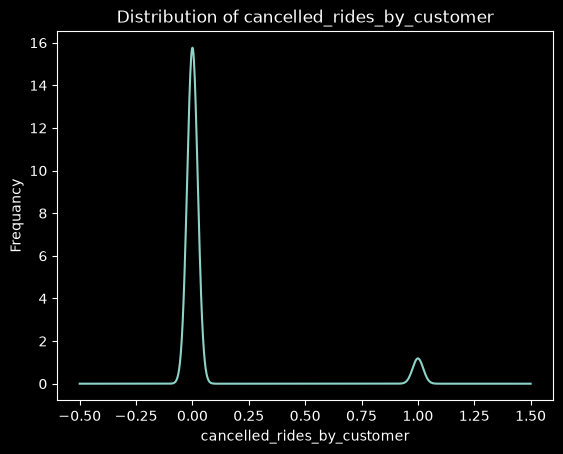

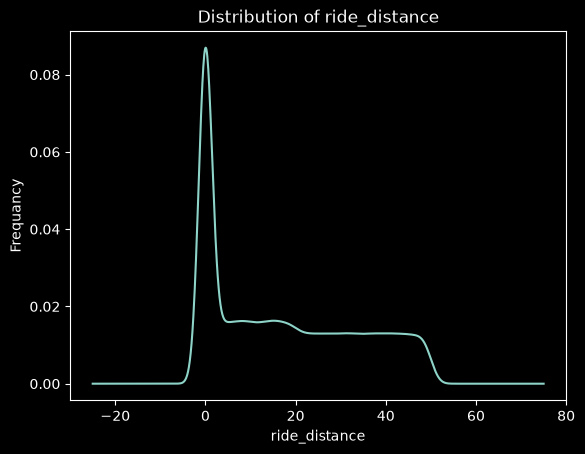

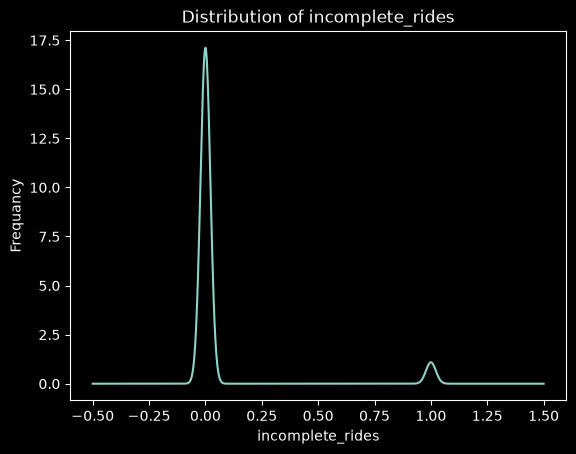

In [56]:
for column in numeric_columns:
    ax=df[column].plot(kind='kde',title=(f'Distribution of {column}'))
    ax.set_xlabel(f'{column}')
    ax.set_ylabel('Frequancy')
    plt.show()

<m>

### 1.5 Importing to postgres

<m>

db_user = 'postgres'
db_password = 'm.fouad9069'
db_host = 'localhost'      
db_port = '5432'           
db_name = 'Uber_DB'

connection_string = f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
engine = create_engine(connection_string)

df.to_sql('uber_bookings', con=engine, if_exists='replace', index=False)

print("Data successfully imported to PostgreSQL!")

<m>

## 2. Analyzing data

<m>

### 2.1 Heatmap 

<m>

In [58]:
numeric_columns=df.select_dtypes(include='number')

In [59]:
cor1=numeric_columns.corr()
cor1

,booking_value,driver_ratings,average_vehicle_time_at_arrival,cancelled_rides_by_driver,customer_rating,average_customer_time_at_arrival,cancelled_rides_by_customer,ride_distance,incomplete_rides
booking_value,1.000000,0.507529,0.087807,-0.401416,0.508034,0.517263,-0.235057,0.417591,0.102625
driver_ratings,0.507529,1.000000,0.192175,-0.590235,0.973656,0.832671,-0.345623,0.714886,-0.318278
average_vehicle_time_at_arrival,0.087807,0.192175,1.000000,-0.040140,0.192557,0.150854,0.301416,0.136116,-0.110518
cancelled_rides_by_driver,-0.401416,-0.590235,-0.040140,1.000000,-0.590826,-0.600986,-0.128540,-0.481811,-0.118370
customer_rating,0.508034,0.973656,0.192557,-0.590826,1.000000,0.833516,-0.345969,0.716289,-0.318597
average_customer_time_at_arrival,0.517263,0.832671,0.150854,-0.600986,0.833516,1.000000,-0.351919,0.654937,0.002967
cancelled_rides_by_customer,-0.235057,-0.345623,0.301416,-0.128540,-0.345969,-0.351919,1.000000,-0.282134,-0.069314
ride_distance,0.417591,0.714886,0.136116,-0.481811,0.716289,0.654937,-0.282134,1.000000,-0.096236
incomplete_rides,0.102625,-0.318278,-0.110518,-0.118370,-0.318597,0.002967,-0.069314,-0.096236,1.000000


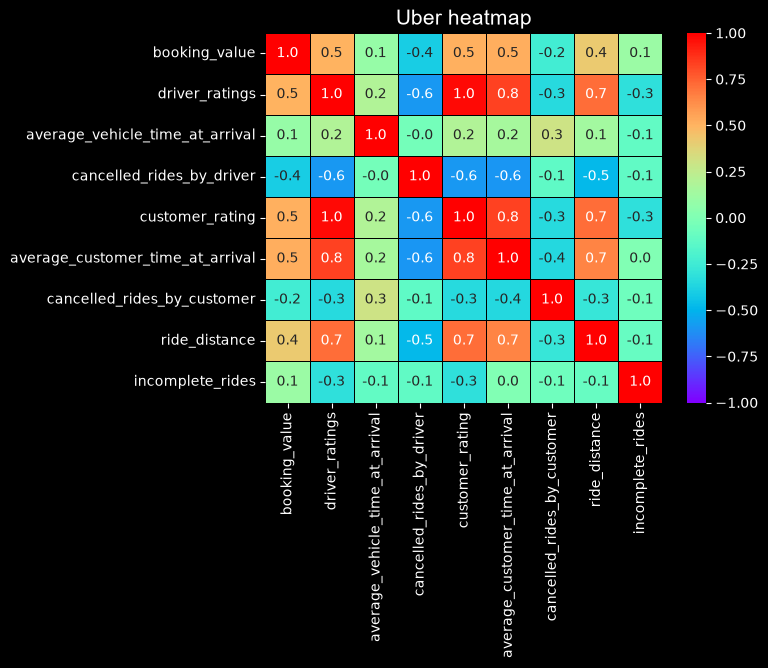

In [62]:
sns.heatmap(cor1,annot=True,vmin=-1,center=0,vmax=1,fmt='1.1f',linewidth=0.5,linecolor='k',cmap='rainbow')
plt.title('Uber heatmap',fontfamily='arial',size=15)
plt.show()

<m>

### 2.2 Booking type revenues

<m>

In [85]:
btr=df.groupby('booking_type')['booking_value'].sum().sort_values(ascending=False)
btr

booking_type
Auto             12878422.0
Go Mini          10338496.0
Go Sedan          9369719.0
Bike              7837697.0
Premier Sedan     6275332.0
eBike             3618485.0
Uber XL           1528032.0
Name: booking_value, dtype: float64

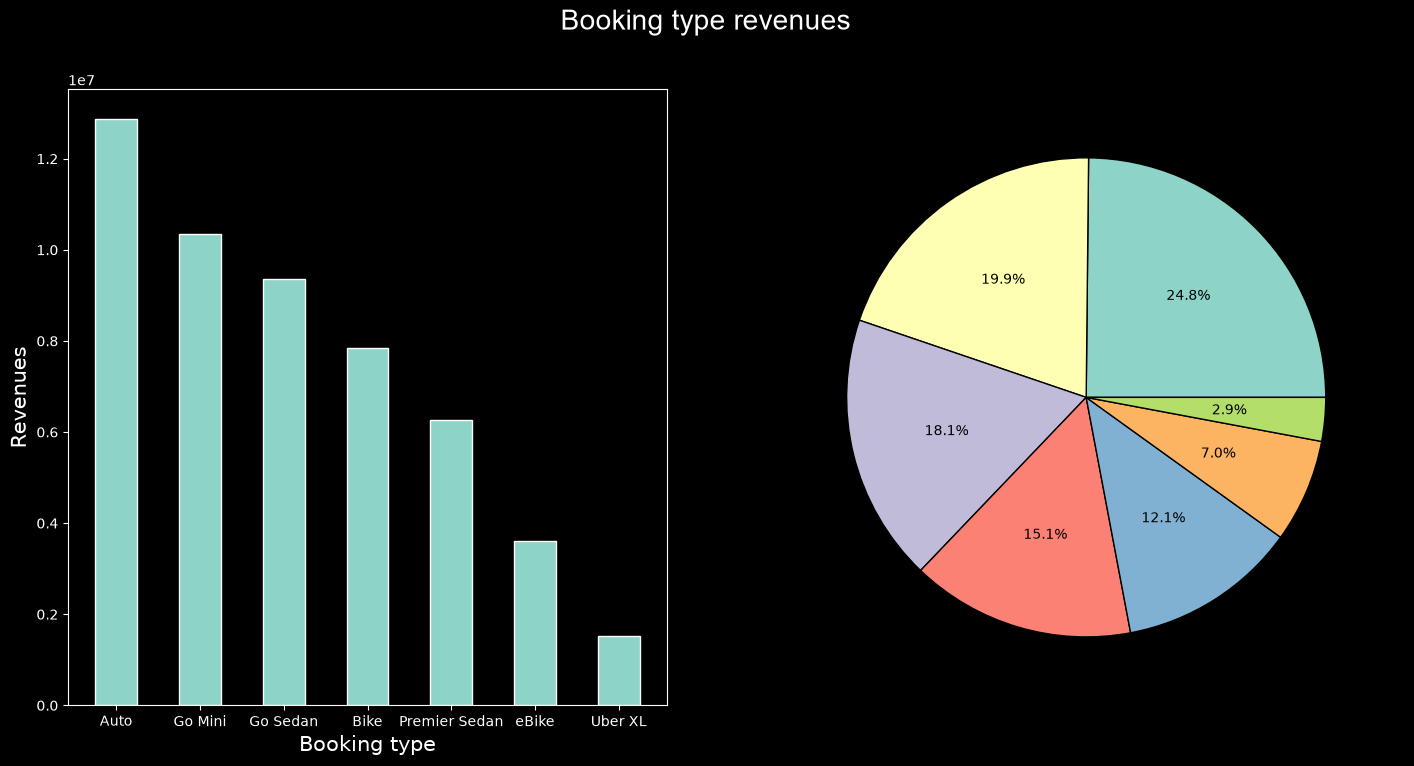

In [86]:
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(17,8))
axis[0].bar(btr.index,btr.values,edgecolor='white',width=0.5)
axis[0].set_xlabel('Booking type',size=15)
axis[0].set_ylabel('Revenues',size=15)
axis[1].pie(btr.values,labels=btr.index,autopct='%1.1f%%',wedgeprops={'edgecolor': 'black'},textprops={'color':'k'})
fig.suptitle('Booking type revenues', fontfamily='arial',size=20)
plt.show()

<m>

### 2.3 Payment method revenues

<f>

In [87]:
pmr=df.groupby('payment_method')['booking_value'].sum().sort_values(ascending=False).head(5)
pmr

payment_method
UPI            23345101.0
Cash           12895649.0
Uber Wallet     6200898.0
Credit Card     5224025.0
Debit Card      4180510.0
Name: booking_value, dtype: float64

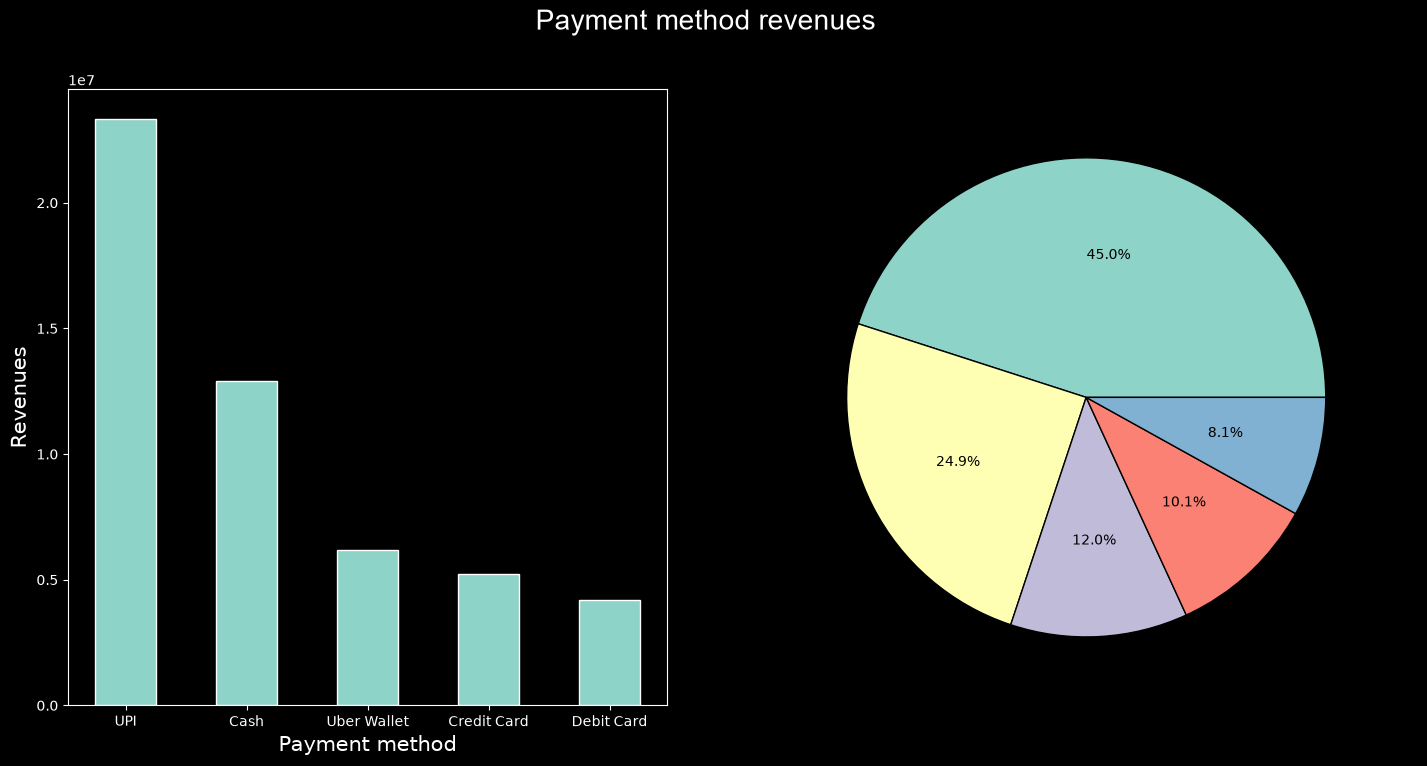

In [88]:
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(17,8))
axis[0].bar(pmr.index,pmr.values,edgecolor='white',width=0.5)
axis[0].set_xlabel('Payment method',size=15)
axis[0].set_ylabel('Revenues',size=15)
axis[1].pie(pmr.values,labels=pmr.index,autopct='%1.1f%%',wedgeprops={'edgecolor': 'black'},textprops={'color':'k'})
fig.suptitle('Payment method revenues', fontfamily='arial',size=20)
plt.show()

<m>

### 2.4 Location with the most revenues

<m>

In [89]:
lmr=df.groupby('pickup_location')['booking_value'].sum().sort_values(ascending=False).head(10)
lmr

pickup_location
Barakhamba Road    341154.0
Khandsa            338502.0
Subhash Chowk      329386.0
Pataudi Chowk      328572.0
Badarpur           327193.0
Tughlakabad        326283.0
AIIMS              325733.0
Inderlok           325358.0
Mayur Vihar        322409.0
Greater Noida      322273.0
Name: booking_value, dtype: float64

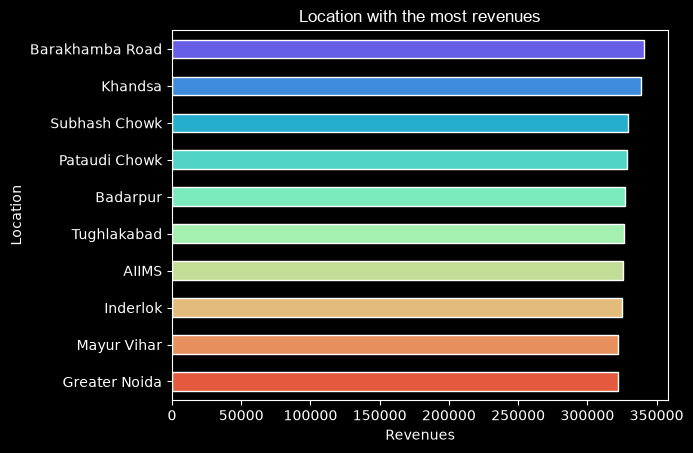

In [90]:
sns.barplot(x=lmr.values,y=lmr.index,edgecolor='white',width=0.5,palette='rainbow')
plt.title('Location with the most revenues',fontfamily='arial')
plt.xlabel('Revenues')
plt.ylabel('Location')
plt.show()

<m>

### 2.5 Booking status frequancy analysis

<m>

In [91]:
bsa=df.groupby('booking_status').size().sort_values(ascending=False)
bsa

booking_status
Completed                93000
Cancelled by Driver      27000
Cancelled by Customer    10500
No Driver Found          10500
Incomplete                9000
dtype: int64

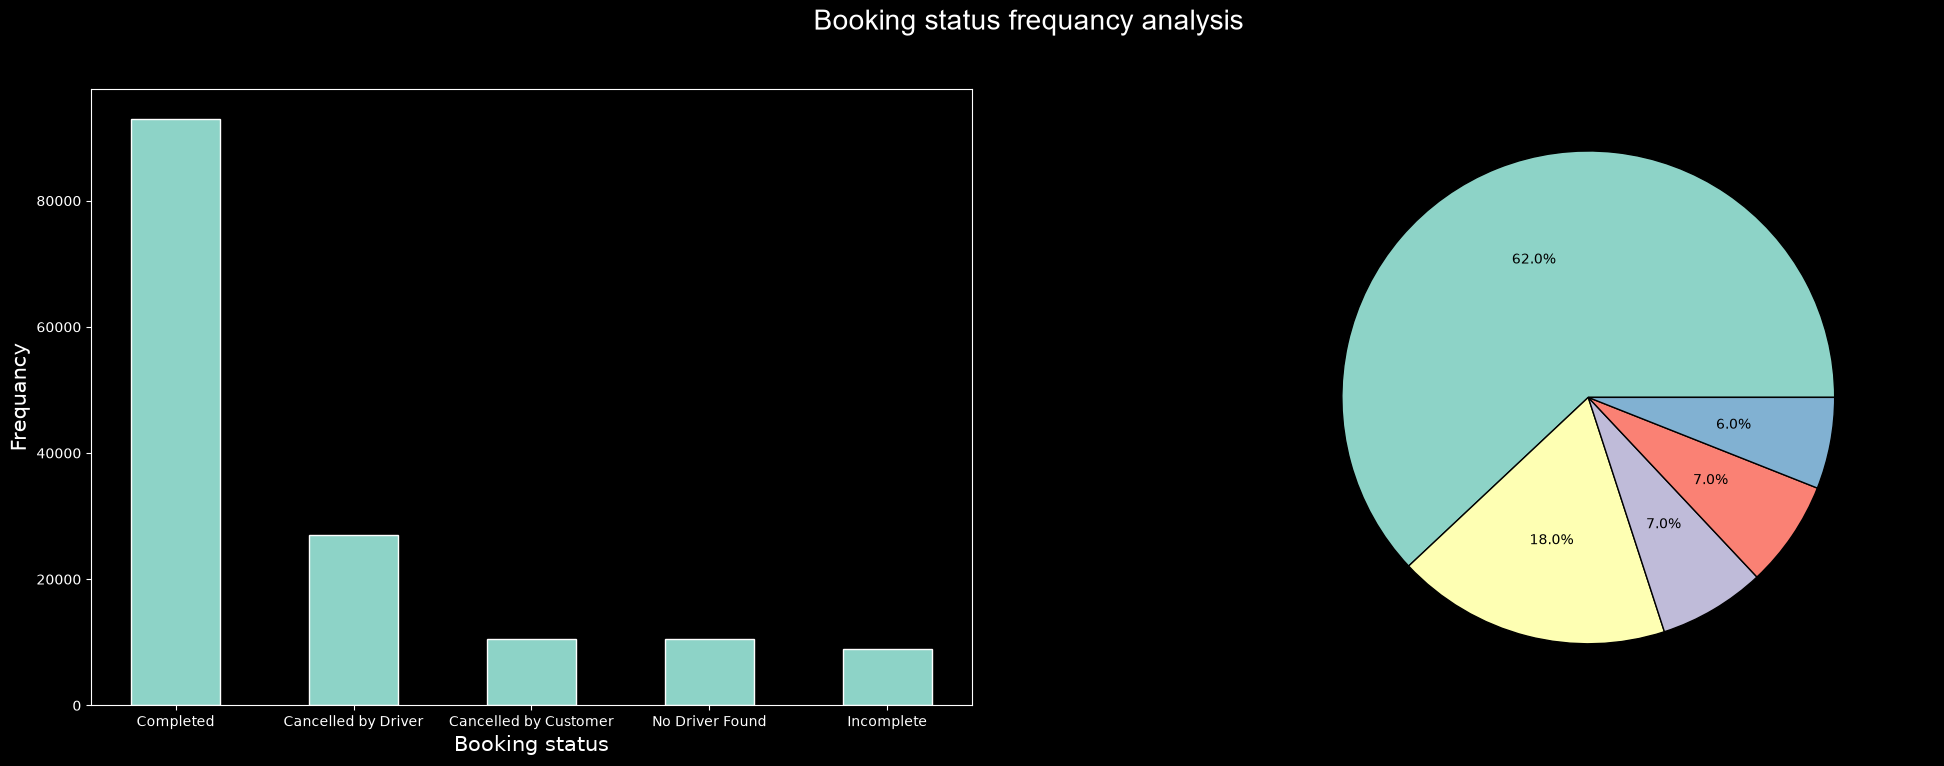

In [92]:
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(25,8))
axis[0].bar(bsa.index,bsa.values,edgecolor='white',width=0.5)
axis[0].set_xlabel('Booking status',size=15)
axis[0].set_ylabel('Frequancy',size=15)
axis[1].pie(bsa.values,labels=bsa.index,autopct='%1.1f%%',wedgeprops={'edgecolor': 'black'},textprops={'color':'k'})
fig.suptitle('Booking status frequancy analysis', fontfamily='arial',size=20)
plt.show()

<m>

### 2.6 Booking type frequancy analysis

<m>

In [93]:
bta=df.groupby('booking_type').size().sort_values(ascending=False)
bta

booking_type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
dtype: int64

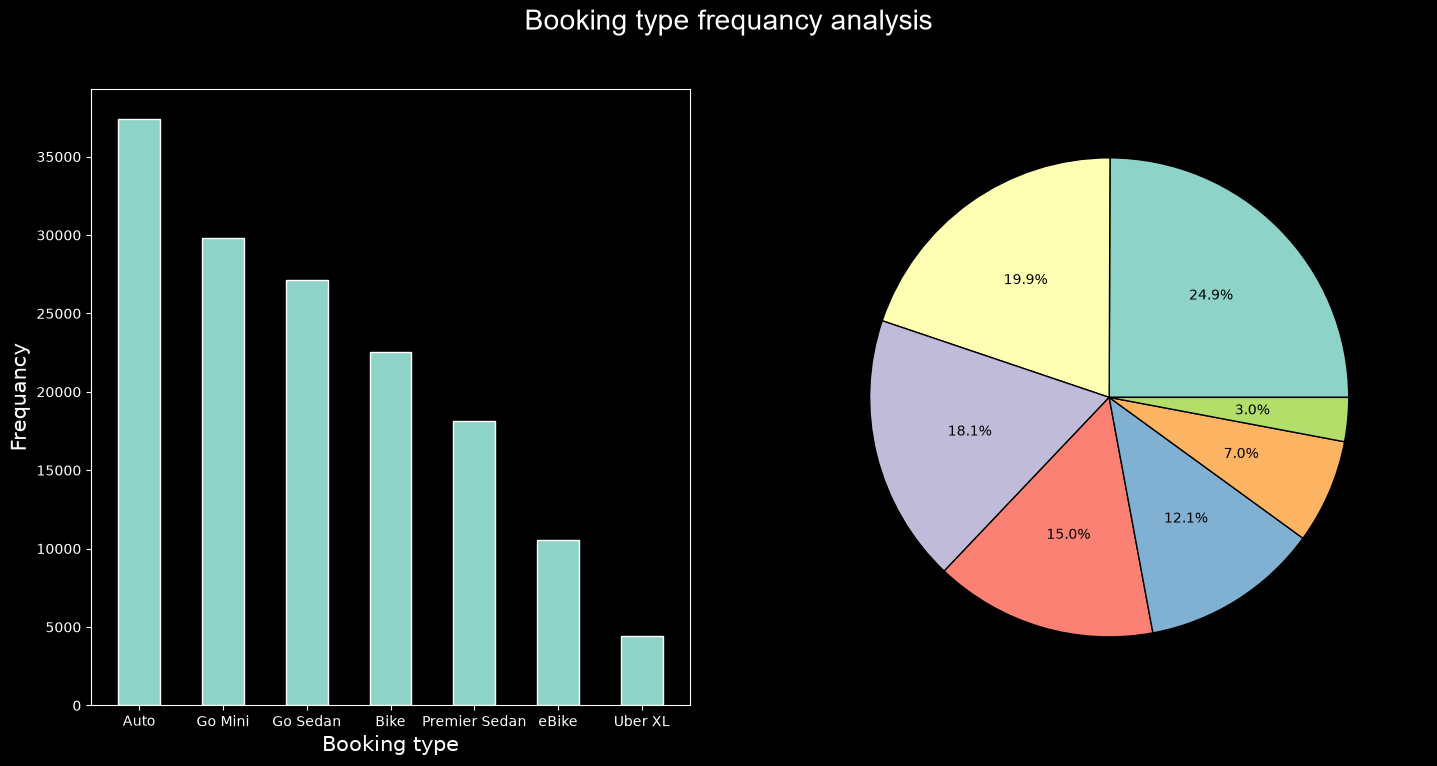

In [94]:
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(17,8))
axis[0].bar(bta.index,bta.values,edgecolor='white',width=0.5)
axis[0].set_xlabel('Booking type',size=15)
axis[0].set_ylabel('Frequancy',size=15)
axis[1].pie(bta.values,labels=bta.index,autopct='%1.1f%%',wedgeprops={'edgecolor': 'black'},textprops={'color':'k'})
fig.suptitle('Booking type frequancy analysis', fontfamily='arial',size=20)
plt.show()

<m>

### 2.7 Payment method frequancy analysis

<m>

In [95]:
pma=df.groupby('payment_method').size().sort_values(ascending=False)
pma

payment_method
incompleted ride    48000
UPI                 45909
Cash                25367
Uber Wallet         12276
Credit Card         10209
Debit Card           8239
dtype: int64

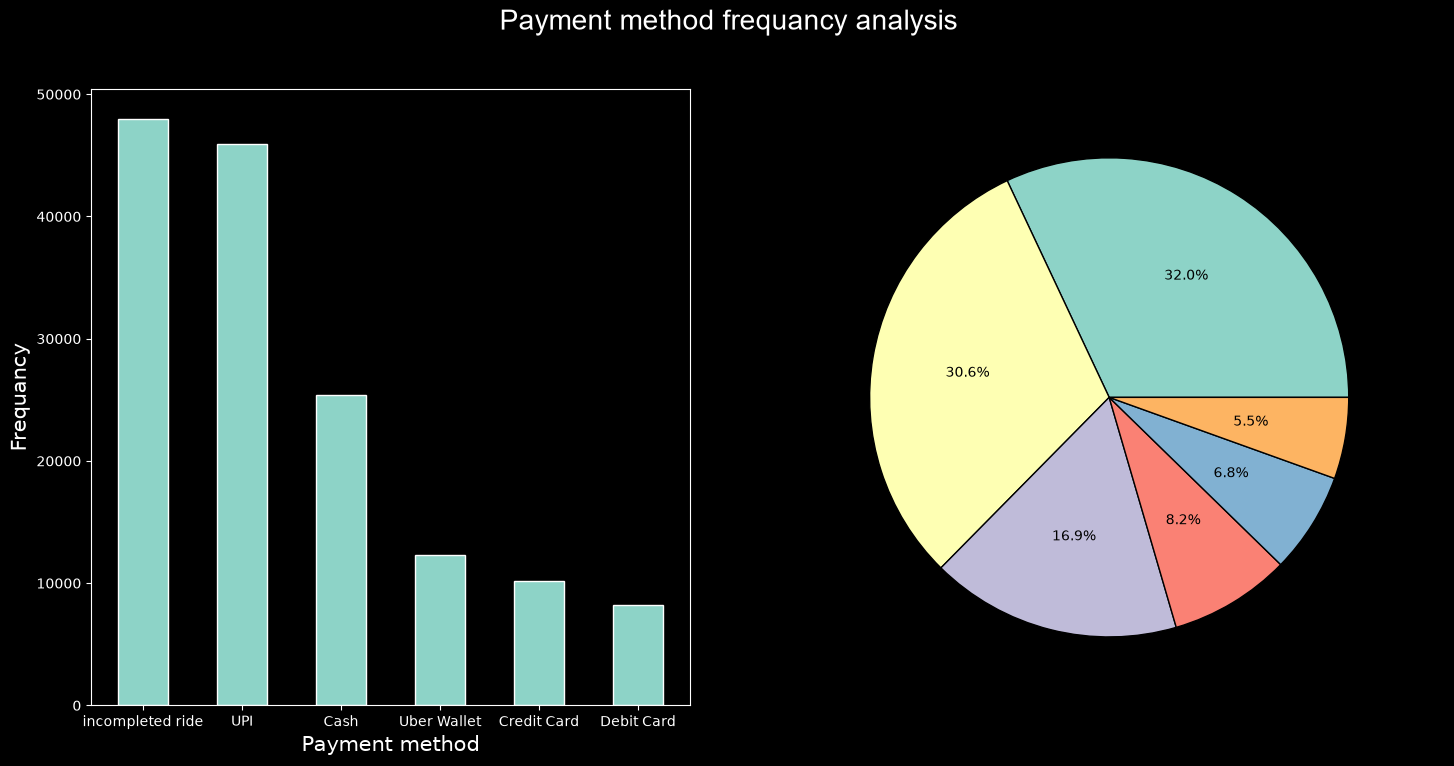

In [96]:
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(17,8))
axis[0].bar(pma.index,pma.values,edgecolor='white',width=0.5)
axis[0].set_xlabel('Payment method',size=15)
axis[0].set_ylabel('Frequancy',size=15)
axis[1].pie(pma.values,labels=pma.index,autopct='%1.1f%%',wedgeprops={'edgecolor': 'black'},textprops={'color':'k'})
fig.suptitle('Payment method frequancy analysis', fontfamily='arial',size=20)
plt.show()

<m>

### 2.8 Driver cancellation reasons frequancy analysis

<m>

In [97]:
df_d_unknown=df[(df['driver_cancellation_reason'] != 'Unknown')]

In [98]:
dcr=df_d_unknown.groupby('driver_cancellation_reason').size().sort_values(ascending=False)
dcr

driver_cancellation_reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
dtype: int64

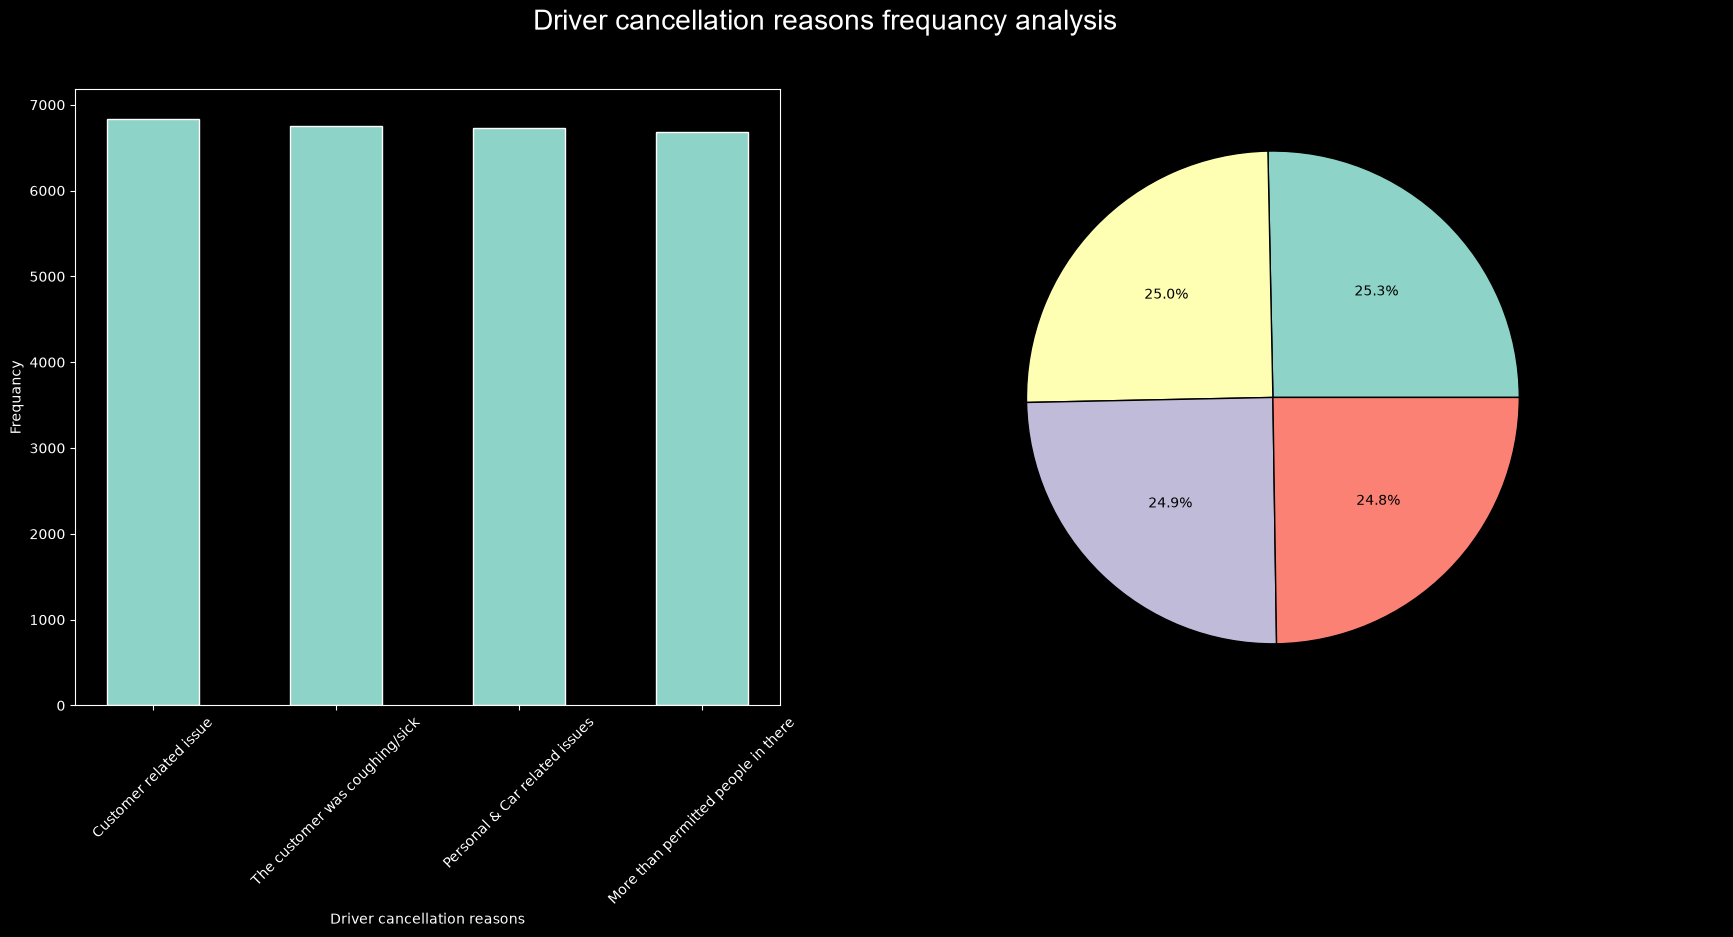

In [99]:
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(20,8))
axis[0].bar(dcr.index,dcr.values,width=0.5,edgecolor='white')
axis[0].set_xlabel('Driver cancellation reasons')
axis[0].set_ylabel('Frequancy')
axis[0].set_xticklabels(dcr.index,rotation=45)
axis[1].pie(dcr.values,labels=dcr.index,autopct='%1.1f%%',wedgeprops={'edgecolor':'black'},textprops={'color':'k'})
fig.suptitle('Driver cancellation reasons frequancy analysis',fontfamily='arial',size=20)
plt.show()

<m>

### 2.9 Customer cancellation reasons frequancy analysis

<m>

In [100]:
df_c_un=df[(df['reason_for_cancelling_by_customer'] != 'Unknown')]

In [101]:
ccr=df_c_un.groupby('reason_for_cancelling_by_customer').size().sort_values(ascending=False)
ccr

reason_for_cancelling_by_customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
dtype: int64

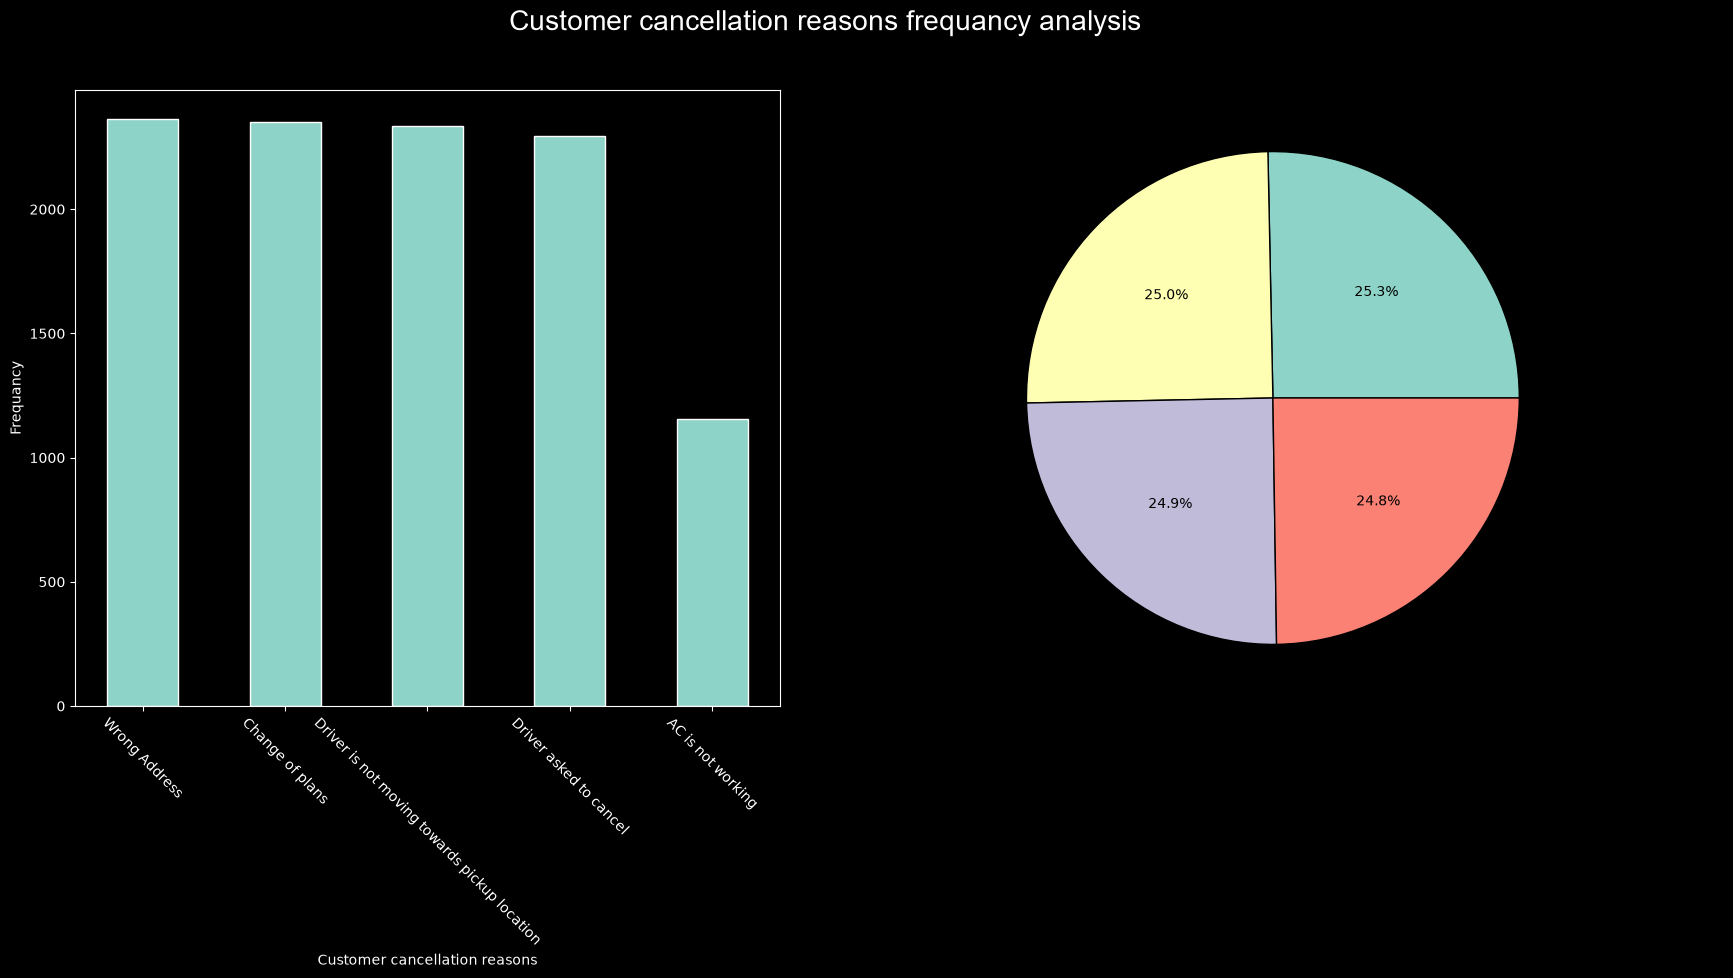

In [102]:
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(20,8))
axis[0].bar(ccr.index,ccr.values,width=0.5,edgecolor='white')
axis[0].set_xlabel('Customer cancellation reasons')
axis[0].set_ylabel('Frequancy')
axis[0].set_xticklabels(ccr.index,rotation=-45)
axis[1].pie(dcr.values,labels=dcr.index,autopct='%1.1f%%',wedgeprops={'edgecolor':'black'},textprops={'color':'k'})
fig.suptitle('Customer cancellation reasons frequancy analysis',fontfamily='arial',size=20)
plt.show()

<m>

### 2.10 Incomplete rides reason frequancy analysis

<m>

In [103]:
df_i_un=df[(df['incomplete_rides_reason'] != 'Unknown')]

In [104]:
inf=df_i_un.groupby('incomplete_rides_reason').size().sort_values(ascending=False)
inf

incomplete_rides_reason
Customer Demand      3040
Vehicle Breakdown    3012
Other Issue          2948
dtype: int64

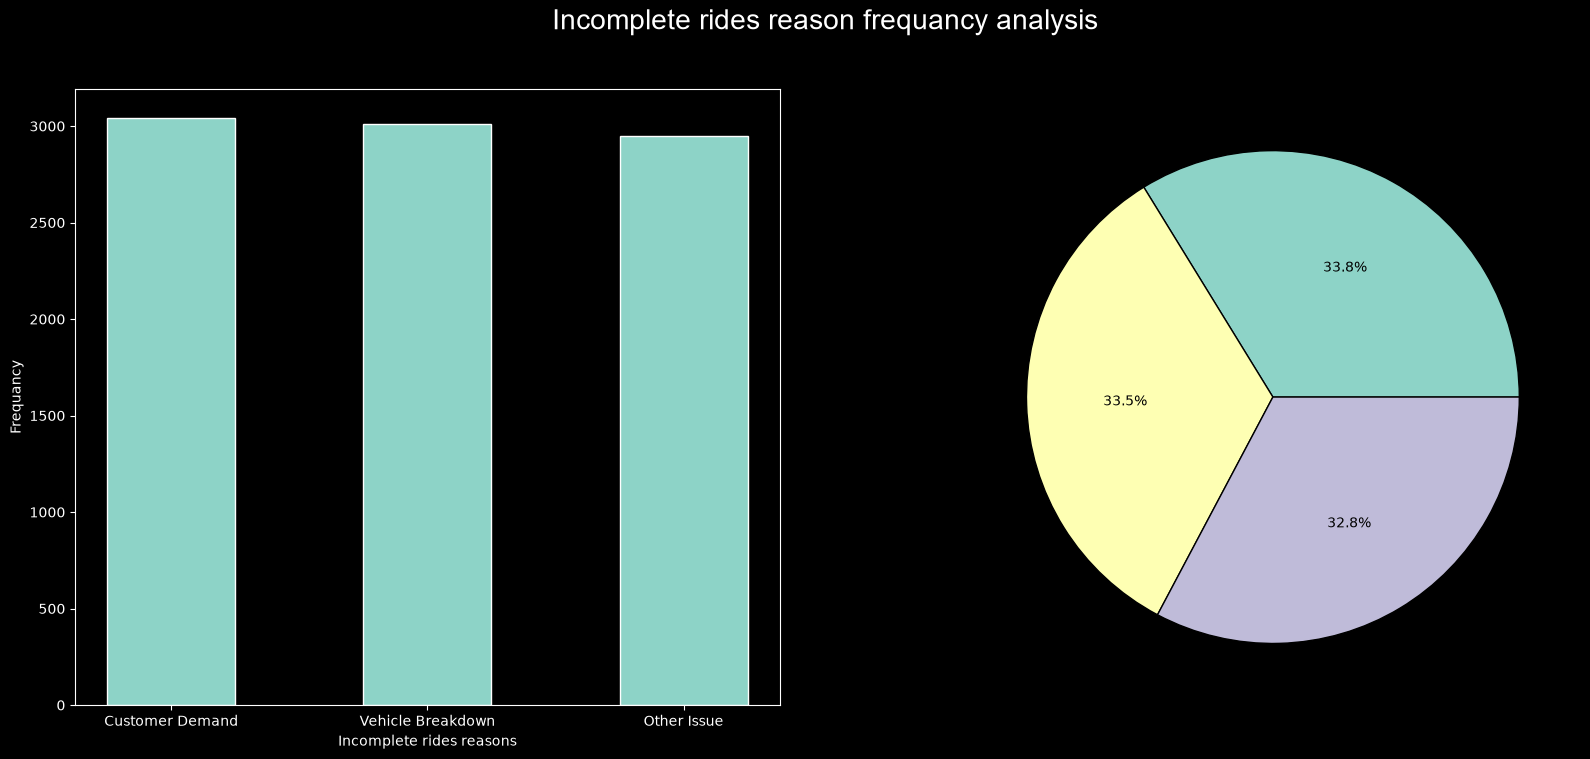

In [105]:
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(20,8))
axis[0].bar(inf.index,inf.values,width=0.5,edgecolor='white')
axis[0].set_xlabel('Incomplete rides reasons')
axis[0].set_ylabel('Frequancy')
axis[1].pie(inf.values,labels=inf.index,autopct='%1.1f%%',wedgeprops={'edgecolor':'black'},textprops={'color':'k'})
fig.suptitle('Incomplete rides reason frequancy analysis',fontfamily='arial',size=20)
plt.show()

<m>

### 2.11 Relation between avg vehicle time at arrival and driver rating

<m>

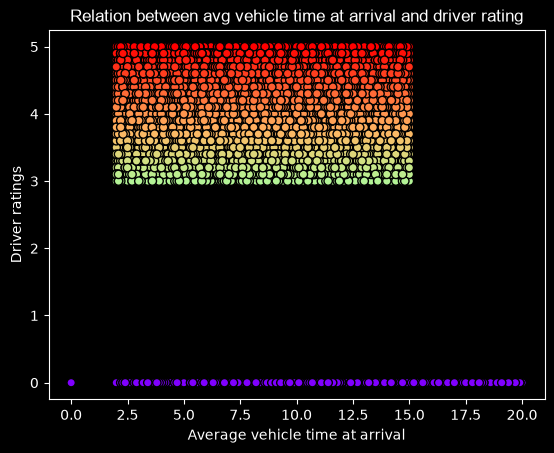

In [108]:
plt.scatter(df['average_vehicle_time_at_arrival'],df['driver_ratings'],c=df['driver_ratings'],edgecolor='k',cmap='rainbow')
plt.title('Relation between avg vehicle time at arrival and driver rating',fontfamily='arial')
plt.xlabel('Average vehicle time at arrival')
plt.ylabel('Driver ratings')
plt.show()

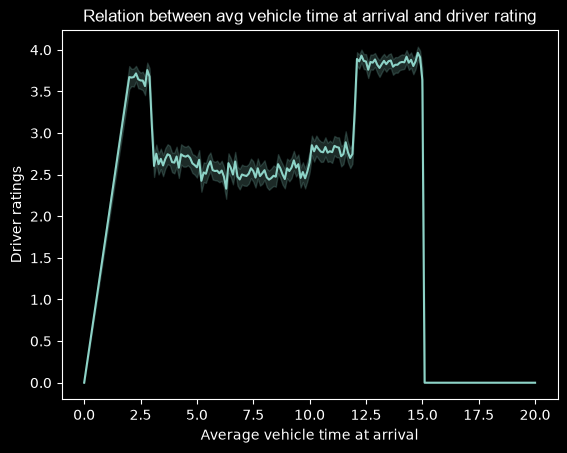

In [109]:
sns.lineplot(x=df['average_vehicle_time_at_arrival'],y=df['driver_ratings'])
plt.title('Relation between avg vehicle time at arrival and driver rating',fontfamily='arial')
plt.xlabel('Average vehicle time at arrival')
plt.ylabel('Driver ratings')
plt.show()

<m>

### 2.12 Relation between avg customer time at arrival and customer rating

<m>

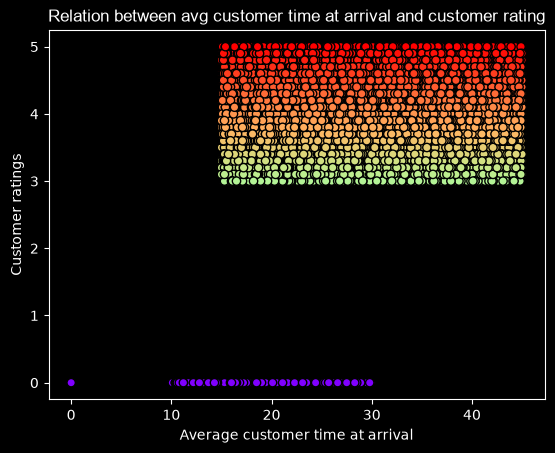

In [110]:
plt.scatter(df['average_customer_time_at_arrival'],df['customer_rating'],c=df['customer_rating'],edgecolor='k',cmap='rainbow')
plt.title('Relation between avg customer time at arrival and customer rating',fontfamily='arial')
plt.xlabel('Average customer time at arrival')
plt.ylabel('Customer ratings')
plt.show()

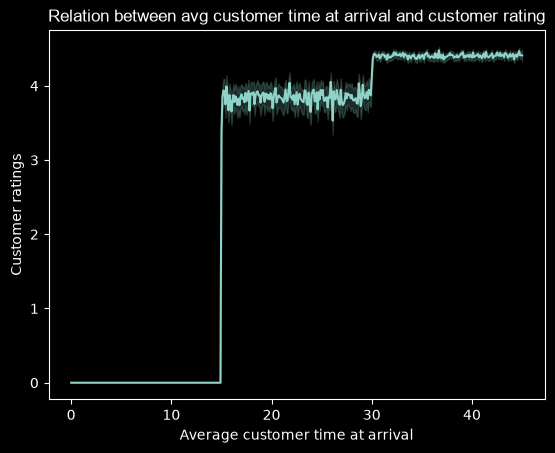

In [111]:
sns.lineplot(x=df['average_customer_time_at_arrival'],y=df['customer_rating'])
plt.title('Relation between avg customer time at arrival and customer rating',fontfamily='arial')
plt.xlabel('Average customer time at arrival')
plt.ylabel('Customer ratings')
plt.show()